# CFR Convergence in Kuhn Poker

This notebook analyzes a vanilla Counterfactual Regret Minimization implementation on Kuhn Poker. Kuhn Poker is a small imperfect-information poker game with three cards: J, Q, and K. Each player receives one private card, then the players make a sequence of pass/check or bet/call decisions.

The goal is to show that CFR converges toward the known game value of Kuhn Poker, which is $-1/18$ for Player 0, and to inspect the learned average strategy.

In [1]:
import time
import matplotlib.pyplot as plt
import kuhn_poker as kp


NUM_ITERATIONS = 500_000
PRINT_EVERY = 100_000
SOLVED_VALUE = -1 / 18

ALL_DEALS = [
    ("J", "Q"), ("J", "K"),
    ("Q", "J"), ("Q", "K"),
    ("K", "J"), ("K", "Q"),
]

## Training setup

Instead of randomly sampling card deals, this experiment iterates over all six possible card deals on every training iteration. This makes the training curve smoother and removes variance from random card sampling.

At each iteration, we record:

- the running average game value for Player 0
- the absolute error from the known solved game value
- the average positive regret

In [2]:
def train(n):
    kp.node_map = {}

    values = []
    regrets = []

    total = 0.0
    start = time.time()

    for i in range(1, n + 1):
        for cards in ALL_DEALS:
            total += kp.cfr(cards, "", 1.0, 1.0)

        avg_value = total / (i * len(ALL_DEALS))
        regret = kp.average_regret(i)

        values.append(avg_value)
        regrets.append(regret)

        if i % PRINT_EVERY == 0:
            elapsed = time.time() - start
            print(
                f"Iteration {i:,} | "
                f"avg: {avg_value:.6f} | "
                f"avg regret: {regret:.6f} | "
                f"time: {elapsed:.2f}s"
            )

    return values, regrets

In [3]:
# Run Training
values, regrets = train(NUM_ITERATIONS)

Iteration 100,000 | avg: -0.055772 | avg regret: 0.012518 | time: 4.36s
Iteration 200,000 | avg: -0.055753 | avg regret: 0.008334 | time: 8.81s
Iteration 300,000 | avg: -0.055801 | avg regret: 0.007533 | time: 13.21s
Iteration 400,000 | avg: -0.055803 | avg regret: 0.006551 | time: 17.59s
Iteration 500,000 | avg: -0.055674 | avg regret: 0.005565 | time: 21.93s


## Average game value convergence

The known game value of Kuhn Poker for Player 0 is $-1/18 \approx -0.0556$. Since Player 0 acts first, this negative value reflects the first-player disadvantage under optimal play.

The CFR running average should approach this solved value as training progresses.

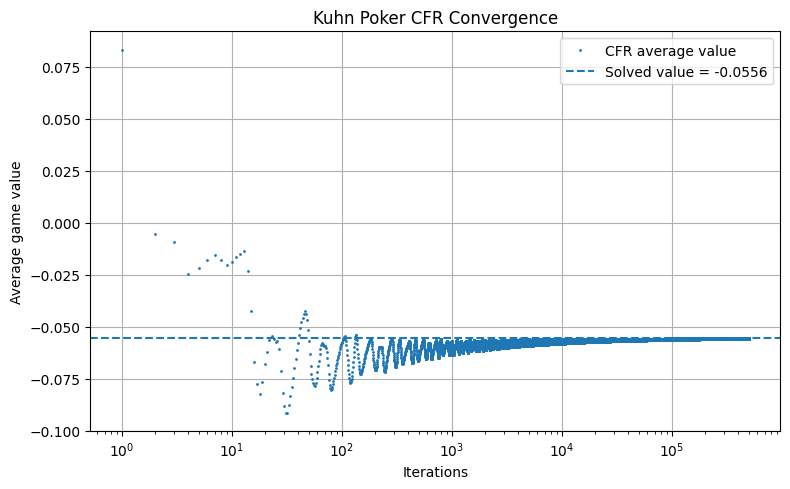

In [4]:
x = range(1, NUM_ITERATIONS + 1)

plt.figure(figsize=(8, 5))
plt.plot(x, values, "o", markersize=1, label="CFR average value")
plt.axhline(SOLVED_VALUE, linestyle="--", label=f"Solved value = {SOLVED_VALUE:.4f}")

plt.xscale("log")
plt.xlabel("Iterations")
plt.ylabel("Average game value")
plt.title("Kuhn Poker CFR Convergence")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The average game value converges toward the solved value. Early iterations move quickly because the regret tables are still changing substantially. Later iterations change more slowly, which is expected for vanilla CFR.

Interestingly, we can see the average game value oscillate back and forth, only tending towards the solved value in the long run. This is because the strategy at each iteration is not itself an equilibrium; CFR updates regrets locally at each information set, which can temporarily overcorrect in different directions. As a result, the *current* strategy can be slightly too aggressive or too passive at different points in training, causing the observed fluctuations in game value.

However, CFR’s convergence guarantee applies to the average strategy, not the instantaneous one. The running average smooths out these oscillations over time, which is why the overall trend still approaches the true game value.


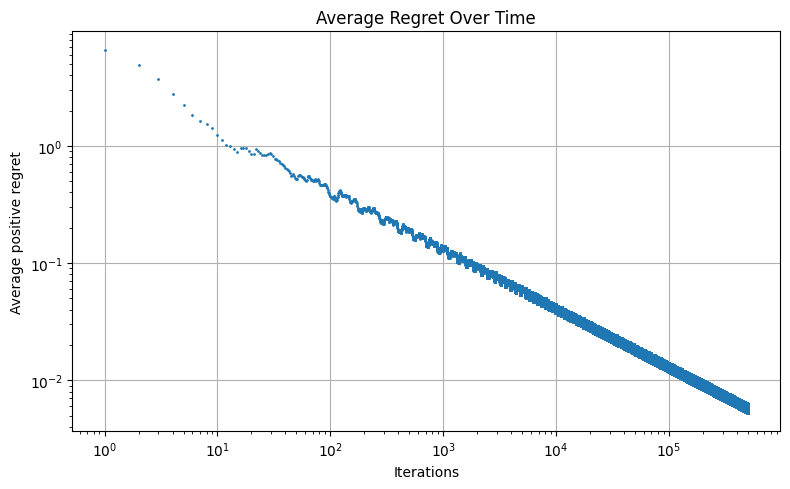

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(x, regrets, "o", markersize=1)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Average positive regret")
plt.title("Average Regret Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()

## Regret over time

In CFR, regret measures how much better an action would have performed compared to the strategy actually used at an information set.

The implementation stores cumulative counterfactual regret for each action at each information set. Here, we plot the average positive regret:

$$

\frac{1}{T} \sum_I \sum_a \max(R_T(I,a), 0)

$$

CFR does not require cumulative regret to go to zero. Instead, the important quantity is average regret, which should decrease as training progresses. Low average regret means that no action at any information set would have been much better in hindsight, which is what drives convergence toward Nash equilibrium.

On a log-log plot, average regret should appear approximately linear because CFR has a sublinear regret bound. In vanilla CFR, cumulative regret grows on the order of $O(\sqrt{T})$, so average regret decreases on the order of $O(1/\sqrt{T})$. Therefore, on a log-log plot of average regret versus iterations, we expect an approximately straight line with slope near $-1/2$. The fact that the plotted regret follows this roughly linear downward trend supports that the implementation is behaving as expected.

In [6]:
print(f"Iterations:               {NUM_ITERATIONS:,}")
print(f"Final average game value: {values[-1]:.8f}")
print(f"Solved game value:        {SOLVED_VALUE:.8f}")
print(f"Average regret:           {regrets[-1]:.8f}")

Iterations:               500,000
Final average game value: -0.05567442
Solved game value:        -0.05555556
Average regret:           0.00556510


In [7]:
print("Average strategy:")
print()

for info_set in sorted(kp.node_map):
    strat = kp.node_map[info_set].get_average_strategy()
    print(f"{info_set:>3}: p={strat['p']:.8f}, b={strat['b']:.8f}")

Average strategy:

  J: p=0.77956975, b=0.22043025
 Jb: p=0.99999950, b=0.00000050
 Jp: p=0.66732974, b=0.33267026
Jpb: p=0.99999968, b=0.00000032
  K: p=0.33723830, b=0.66276170
 Kb: p=0.00000050, b=0.99999950
 Kp: p=0.00000200, b=0.99999800
Kpb: p=0.00000074, b=0.99999926
  Q: p=0.99999763, b=0.00000238
 Qb: p=0.66557671, b=0.33442329
 Qp: p=0.99999617, b=0.00000383
Qpb: p=0.44544902, b=0.55455098


## Interpreting the learned strategy

The learned strategy matches the qualitative structure of Kuhn Poker equilibrium. A J hand represents what actions should be taken when possessing a J and being Player 0. A Jb hand represents what actions should be taken when possessing a J with the betting history being "b" (Player 0 having bet), and so on with Jpb being what actions player 0 should take with the history being a check and a bet.

At the first decision, strong hands such as K are bet aggressively, weak hands such as J are sometimes used as bluffs, and Q is usually checked. This makes sense because Q is a medium-strength hand: it is too weak to value bet, but too strong to turn into a pure bluff.

When facing a bet, the learned strategy usually folds J, calls with K, and mixes with Q. This is the central equilibrium behavior in Kuhn Poker: players cannot use deterministic strategies without becoming exploitable, so CFR learns mixed strategies that balance value bets and bluffs. This is why Kuhn Poker is used - it is a very simplistic two person imperfect information game where interesting mixed strategies like the above are optimal.